# Dow 10 條件 TimeDiff × FinRL：壓力情境資料增強（第一輪總結）

以 **看過 2008 的 Dow 10 條件 TimeDiff** 生成三組指定報酬／波動率的崩盤情境，混入 FinRL（10 檔＋現金、PPO）訓練，
比較 **A：只用真實**、**B20：20% 合成**、**B50：50% 合成** 在 2020–2022 的表現。

本 notebook **只分析已保存的結果，不重訓、不重新取樣**。FinRL 結果由本 repo 的 `results/scenario_mix/v1/` 重算。
TimeDiff 的生成輸出（`outputs/dow10_cond/`）不在本 repo；若旁邊有 TimeDiff 資料夾且含這些檔案，會直接重算，
否則使用生成當時 `summary.csv`／`generation.json` 的**記錄值**，並在表格的 `provenance` 欄標示。

| 階段 | 期間 |
|---|---|
| TimeDiff 訓練 target | 2005-01 – 2017-12（含 2008 海嘯） |
| TimeDiff 選模 | 2018–2019 |
| 生成起點 | 2010-01 – 2017-12 |
| FinRL 訓練／選模／測試 | 2010–2017／2018–2019／2020–2022 |

報酬為 **10 檔每日再平衡等權組合的 21 日累積簡單報酬**；波動率為 **組合日 log return 樣本標準差 × √252**。

## 1. 執行與資料來源

在 `FinRL_Exp/analysis/` 開啟並從頭執行即可，或在 FinRL_Exp 目錄執行：

```bash
jupyter nbconvert --to notebook --execute --inplace analysis/scenario_mix_v1_summary.ipynb
```

預設 TimeDiff 與 FinRL_Exp 在同一個上層資料夾；若不是，設定環境變數 `TIMEDIFF_ROOT`。
下格列出每個來源是否存在。TimeDiff 檔案缺少時，表格改用記錄值；需要原始路徑的圖（分布、樣本）則略過。

In [23]:
from pathlib import Path
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'finrl/experiments/scenario_mix.py').exists())
TD = Path(os.environ.get('TIMEDIFF_ROOT', ROOT.parent / 'TimeDiff')).resolve()
OUT = TD / 'outputs' / 'dow10_cond'
SRC = {
    'prices (2004-)':          TD / 'datasets/dow10/prices_2004.csv',
    'prices (2008-10-)':       TD / 'datasets/dow10/prices.csv',
    'model: no crash':         OUT / 'train_10k',
    'model: with 2008':        OUT / 'train_2005',
    'diag: no crash':          OUT / 'diagnostic',
    'calibration 1':           OUT / 'calibration',
    'calibration 2':           OUT / 'calibration2',
    'calibration 3':           OUT / 'calibration3',
    'diag: final':             OUT / 'diagnostic_final',
    'rl paths':                OUT / 'rl_paths',
    'FinRL v1':                ROOT / 'results/scenario_mix/v1_test2025',
    'FinRL v1 2025':           ROOT / 'results/scenario_mix/v1_test2025',
    'FinRL sanity (optional)': ROOT / 'results/scenario_mix/sanity',
}
def _rel(p):
    try:
        return str(p.relative_to(ROOT.parent))
    except ValueError:
        return str(p)
display(pd.DataFrame({'path (relative to parent folder)': {k: _rel(v) for k, v in SRC.items()},
                      'exists': {k: v.exists() for k, v in SRC.items()}}))
have = {k: v.exists() for k, v in SRC.items()}
EXPORT = ROOT / 'analysis' / 'scenario_mix_v1_export'
EXPORT.mkdir(parents=True, exist_ok=True)

TICKERS = ['AAPL', 'AMGN', 'CRM', 'CSCO', 'IBM', 'INTC', 'MSFT', 'NKE', 'VZ', 'WMT']
TARGETS = [(-0.10, 0.40), (-0.20, 0.60), (-0.30, 0.80)]
CHOSEN_INPUTS = [(-0.10, 0.50), (-0.23, 1.00), (-0.36, 1.40)]
NAMES = {0: 'S1 −10%/40%', 1: 'S2 −20%/60%', 2: 'S3 −30%/80%'}
COLORS = {0: 'tab:orange', 1: 'tab:red', 2: 'darkred'}
TOL_R, TOL_V = 0.02, 0.05
pct = lambda x: f'{x:+.1%}'

def portfolio_stats(rc):
    # rc [..., 21, 10] daily log returns -> R, vol of the daily-rebalanced EW portfolio
    rp = np.log(np.exp(rc).mean(axis=-1))
    return np.expm1(rp.sum(axis=-1)), rp.std(axis=-1, ddof=1) * np.sqrt(252)

def mean_corr(rc):
    mask = ~np.eye(rc.shape[-1], dtype=bool)
    return np.array([np.corrcoef(x.T)[mask].mean() if np.all(x.std(0) > 0) else np.nan for x in rc])

def ew_path(close_rel):
    gross = close_rel[..., 1:, :] / close_rel[..., :-1, :]
    v = np.cumprod(gross.mean(axis=-1), axis=-1)
    return np.concatenate([np.ones(v.shape[:-1] + (1,)), v], axis=-1)

def load_prices(path):
    p = pd.read_csv(path, parse_dates=['date'])
    return {c: p.pivot(index='date', columns='tic', values=c)[TICKERS] for c in ('close', 'high', 'low')}

# Values printed by `dow10_cond_experiment.py generate` at generation time (2026-10-05).
# Used only when the TimeDiff output folder is not available next to this repo.
_COLS = ['target_return', 'target_volatility', 'n_paths', 'realized_return_mean', 'realized_vol_mean',
         'mean_pairwise_corr', 'max_abs_daily_return']
RECORDED = {
    'diag: no crash': [(-.10, .40, 1800, -.101437, .481881, .758203, .196412),
                       (-.20, .60, 1800, -.159009, .998571, .886802, .386918),
                       (-.30, .80, 1800, -.183375, 1.737763, .915712, .699911)],
    'calibration 1': [(-.10, .40, 480, -.105356, .336674, .586248, .141315), (-.10, .50, 480, -.100514, .390341, .655952, .170188),
                      (-.10, .60, 480, -.091671, .440923, .703107, .147603), (-.20, .60, 480, -.211749, .433401, .691754, .171496),
                      (-.20, .80, 480, -.191931, .530815, .759780, .212046), (-.20, 1.00, 480, -.165996, .617052, .786881, .207674),
                      (-.30, .80, 480, -.310727, .517181, .744240, .205631), (-.30, 1.00, 480, -.291350, .611073, .787513, .222733),
                      (-.30, 1.20, 480, -.261194, .702746, .807051, .232791)],
    'calibration 2': [(-.10, .50, 480, -.101209, .390367, .657439, .147857), (-.22, 1.00, 480, -.194270, .618844, .789561, .217305),
                      (-.23, 1.00, 480, -.207050, .621939, .789759, .214801), (-.24, 1.05, 480, -.207453, .638192, .792670, .215179),
                      (-.32, 1.30, 480, -.267996, .751837, .816820, .263788), (-.34, 1.40, 480, -.279099, .791370, .819785, .248419),
                      (-.36, 1.50, 480, -.288352, .838599, .825682, .265304)],
    'calibration 3': [(-.38, 1.35, 480, -.336156, .761444, .814014, .273186), (-.40, 1.40, 480, -.347048, .783196, .819282, .287176),
                      (-.42, 1.40, 480, -.366006, .786855, .818449, .293208)],
    'diag: final': [(-.10, .50, 1600, -.100246, .390499, .655919, .160974), (-.23, 1.00, 1600, -.205097, .618176, .788907, .237797),
                    (-.36, 1.40, 1600, -.303768, .789322, .820305, .264298)],
    'rl paths': [(-.10, .50, 2013, -.095080, .387325, .651429, .164801), (-.23, 1.00, 2013, -.201540, .613575, .785814, .219586),
                 (-.36, 1.40, 2013, -.299531, .784413, .817095, .277473)],
}
RECORDED_REAL_REF = {'max_return_drop': -.2667755875709595, 'max_vol': .8091733027847133, 'mean_pairwise_corr': .7385767774300086}

def read_summary(name):
    d = SRC[name]
    if (d / 'summary.csv').exists():
        s = pd.read_csv(d / 'summary.csv'); s['provenance'] = 'file'
    elif name in RECORDED:
        s = pd.DataFrame(RECORDED[name], columns=_COLS); s['provenance'] = 'recorded'
    else:
        return None
    s.insert(0, 'source', name)
    return s

def note(msg):
    display(Markdown(f'> {msg}'))

,path (relative to parent folder),exists
prices (2004-),TimeDiff/datasets/dow10/prices_2004.csv,True
prices (2008-10-),TimeDiff/datasets/dow10/prices.csv,True
model: no crash,TimeDiff/outputs/dow10_cond/train_10k,True
model: with 2008,TimeDiff/outputs/dow10_cond/train_2005,True
diag: no crash,TimeDiff/outputs/dow10_cond/diagnostic,True
calibration 1,TimeDiff/outputs/dow10_cond/calibration,True
calibration 2,TimeDiff/outputs/dow10_cond/calibration2,True
calibration 3,TimeDiff/outputs/dow10_cond/calibration3,True
diag: final,TimeDiff/outputs/dow10_cond/diagnostic_final,True
rl paths,TimeDiff/outputs/dow10_cond/rl_paths,True


## 2. 資料與切分核對

核對價格檔的股票、期間與筆數，以及兩個生成器的切分與選模結果。
硬性要求：**所有訓練 target 與選模都在 2020 年以前結束**，測試期 2020–2022 未被生成器使用。

In [24]:
rows = []
for name in ['prices (2004-)', 'prices (2008-10-)']:
    if have[name]:
        p = pd.read_csv(SRC[name], parse_dates=['date'])
        assert sorted(p.tic.unique()) == sorted(TICKERS), 'unexpected tickers'
        assert (p.groupby('date').tic.nunique() == 10).all(), 'missing tickers on some dates'
        rows.append({'file': name, 'first': p.date.min().date(), 'last': p.date.max().date(),
                     'trading days': p.date.nunique(), 'rows': len(p)})
if rows:
    display(pd.DataFrame(rows))
else:
    note('本機沒有 TimeDiff 價格檔（datasets/dow10/）；資料期間見上方說明：2004-07-01 至 2022-12-30，10 檔還原權值日價格。')

META = {}
rows = []
for name in ['model: no crash', 'model: with 2008']:
    f = SRC[name] / 'metadata.json'
    if not f.exists():
        continue
    m = json.loads(f.read_text())
    META[name] = m
    cfg = m.get('training_config', {})
    assert pd.Timestamp(m['val_end']) < pd.Timestamp('2020-01-01'), 'generator saw the test period'
    rows.append({'model': name, 'target_start': cfg.get('target_start', m.get('target_start')),
                 'train_end': m['train_end'], 'val_end': m['val_end'],
                 'train windows': m['split_windows']['train'], 'val windows': m['split_windows']['validation'],
                 'steps': cfg.get('steps'), 'lambda': cfg.get('lambda_condition'),
                 'best step': m['best_step'], 'best val condition MSE': round(m['best_validation_condition_mse'], 4),
                 'data sha256': m['data_sha256'][:12]})
if rows:
    display(pd.DataFrame(rows))
else:
    note('本機沒有生成器 metadata.json。記錄設定：看過 2008 的模型 target 2005-01-03 起、訓練至 2017-12-31、2018–2019 選模、10,000 步、λ=0.1；'
         '對照模型 target 2009-04-01 起，其餘相同。')

,file,first,last,trading days,rows
0,prices (2004-),2004-07-01,2022-12-30,4659,46590
1,prices (2008-10-),2008-10-01,2022-12-30,3588,35880


,model,target_start,train_end,val_end,train windows,val windows,steps,lambda,best step,best val condition MSE,data sha256
0,model: no crash,2009-04-01,2017-12-31,2019-12-31,2184,483,10000,0.1,1750,0.1856,e1e5069543a5
1,model: with 2008,2005-01-02,2017-12-31,2019-12-31,3252,483,10000,0.1,3750,0.1258,7c52d084e8bf


## 3. 生成器訓練過程

左：diffusion loss（不含條件懲罰）；右：完整取樣後的標準化條件 MSE（選模依據，越低越好）。
記錄的是當下 batch 的值，不是 epoch 平均；圓點為選到的 checkpoint。

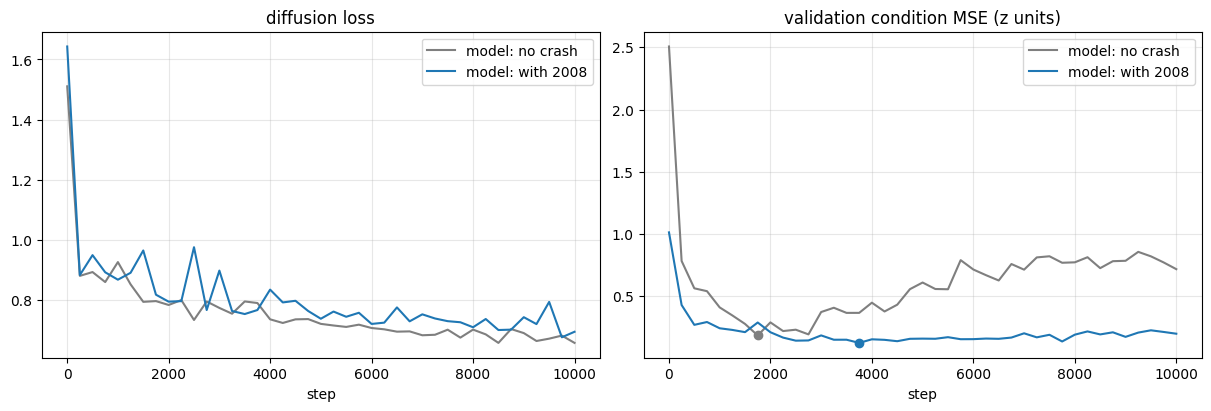

In [25]:
def plot_generator_training():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for name, color in [('model: no crash', 'tab:gray'), ('model: with 2008', 'tab:blue')]:
        f = SRC[name] / 'training.csv'
        if not f.exists():
            continue
        log = pd.read_csv(f)
        axes[0].plot(log.step, log.diffusion_loss, color=color, label=name)
        axes[1].plot(log.step, log.validation_condition_mse, color=color, label=name)
        if name in META:
            b = META[name]['best_step']
            axes[1].scatter([b], log.loc[log.step == b, 'validation_condition_mse'], color=color, zorder=3)
    for ax, t in zip(axes, ['diffusion loss', 'validation condition MSE (z units)']):
        ax.set_title(t); ax.set_xlabel('step'); ax.grid(alpha=.3); ax.legend()
    fig.savefig(EXPORT / 'generator_training.png', dpi=130)
    plt.show()

if any((SRC[n] / 'training.csv').exists() for n in ['model: no crash', 'model: with 2008']):
    plot_generator_training()
else:
    note('本機沒有生成器 training.csv，略過訓練曲線。')

## 4. 生成器需要看過崩盤

同樣三個目標，比較 **未看過崩盤**（target 2009-04 起）與 **看過 2008**（target 2005 起）兩個生成器的實際輸出（未校準，輸入＝目標）。
下表另列訓練 target 中落在命中容許範圍（報酬 ±2 百分點、波動 ±5 百分點）內的窗口數，以及目標在訓練條件分布中的標準化距離。
窗口彼此重疊，不能當成獨立事件數。

In [26]:
def pick(summary, targets):
    if summary is None:
        return None
    key = list(zip(summary.target_return.round(4), summary.target_volatility.round(4)))
    idx = [key.index(t) for t in targets if t in key]
    return summary.iloc[idx] if idx else None

a = pick(read_summary('diag: no crash'), TARGETS)
b = pick(read_summary('calibration 1'), TARGETS)
cols = ['target_return', 'target_volatility', 'realized_return_mean', 'realized_vol_mean',
        'mean_pairwise_corr', 'max_abs_daily_return', 'n_paths', 'provenance']
parts = []
for label, s in [('no crash (2009-2017)', a), ('with 2008 (2005-2017)', b)]:
    if s is None:
        note(f'{label}: 找不到對應的 summary，略過。')
        continue
    parts.append(s[cols].assign(model=label))
if parts:
    t = pd.concat(parts).set_index(['model', 'target_return', 'target_volatility'])
    display(t.style.format({'realized_return_mean': '{:+.1%}', 'realized_vol_mean': '{:.1%}',
                            'mean_pairwise_corr': '{:.2f}', 'max_abs_daily_return': '{:.1%}'}))
    t.to_csv(EXPORT / 'crash_exposure_comparison.csv')

rows = []
for name in ['model: no crash', 'model: with 2008']:
    f = SRC[name] / 'train_conditions.csv'
    if not f.exists() or name not in META:
        note(f'{name}: 沒有 train_conditions.csv／metadata.json，無法計算歷史支持（需 TimeDiff 輸出資料夾）。')
        continue
    c = pd.read_csv(f)[['return', 'volatility']].to_numpy()
    sc = META[name]['condition_scaler']
    z = (c - np.array(sc['mean'])) / np.array(sc['scale'])
    for r, v in TARGETS:
        tz = (np.array([r, v]) - np.array(sc['mean'])) / np.array(sc['scale'])
        near = (np.abs(c[:, 0] - r) <= TOL_R) & (np.abs(c[:, 1] - v) <= TOL_V)
        rows.append({'model': name, 'target': f'{r:+.0%}/{v:.0%}', 'windows within tolerance': int(near.sum()),
                     'nearest distance (z)': np.sqrt(((z - tz) ** 2).sum(1)).min(),
                     'worst training R': c[:, 0].min(), 'max training vol': c[:, 1].max()})
if rows:
    display(pd.DataFrame(rows).style.format({'nearest distance (z)': '{:.2f}', 'worst training R': '{:+.1%}',
                                             'max training vol': '{:.1%}'}))

,model,target,windows within tolerance,nearest distance (z),worst training R,max training vol
0,model: no crash,-10%/40%,3,0.42,-11.3%,42.1%
1,model: no crash,-20%/60%,0,4.53,-11.3%,42.1%
2,model: no crash,-30%/80%,0,8.92,-11.3%,42.1%
3,model: with 2008,-10%/40%,5,0.22,-26.7%,80.9%
4,model: with 2008,-20%/60%,0,0.58,-26.7%,80.9%
5,model: with 2008,-30%/80%,0,0.92,-26.7%,80.9%


## 5. 條件校準

看過 2008 的生成器，報酬大致準確，但波動偏低。以小網格找出實際輸出最接近目標的輸入：
調高輸入波動，實際波動只上升約一半，同時實際報酬變得較不負；因此報酬輸入也要往下補償。

左：輸入波動 vs 實際波動；右：輸入報酬 vs 實際報酬。星號為最終選用的三組輸入（`diagnostic_final`）。
**summary.csv 的 hit_rate／MAE 是對輸入值計算的，校準後不具意義；以下只看實際生成的報酬與波動。**

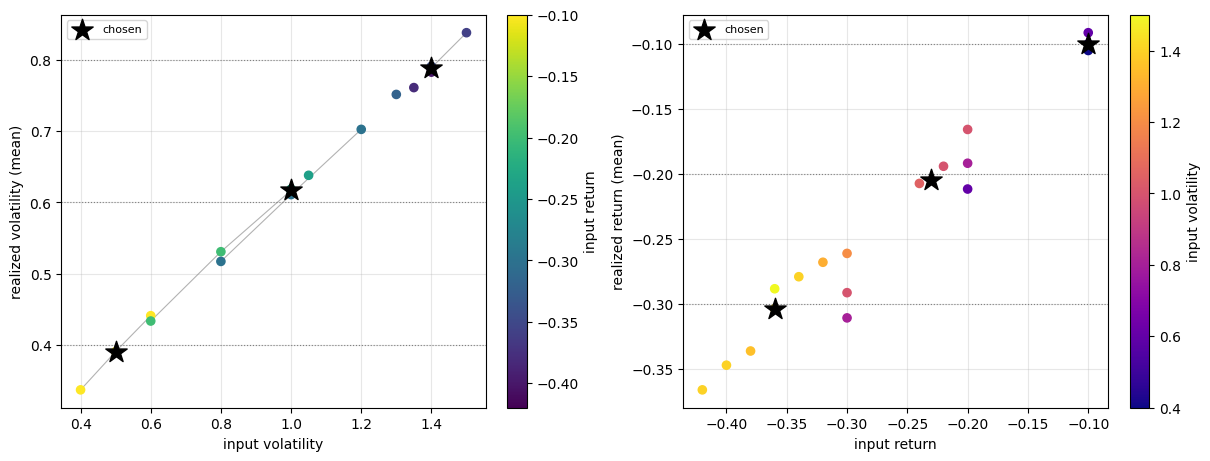

,source,input R,input vol,n_paths,realized_return_mean,realized_vol_mean,mean_pairwise_corr,max_abs_daily_return,provenance
0,calibration 1,-0.100000,0.400000,480,-10.5%,33.7%,0.59,14.1%,file
2,calibration 1,-0.100000,0.600000,480,-9.2%,44.1%,0.70,14.8%,file
3,calibration 1,-0.200000,0.600000,480,-21.2%,43.3%,0.69,17.1%,file
4,calibration 1,-0.200000,0.800000,480,-19.2%,53.1%,0.76,21.2%,file
5,calibration 1,-0.200000,1.000000,480,-16.6%,61.7%,0.79,20.8%,file
6,calibration 1,-0.300000,0.800000,480,-31.1%,51.7%,0.74,20.6%,file
7,calibration 1,-0.300000,1.000000,480,-29.1%,61.1%,0.79,22.3%,file
8,calibration 1,-0.300000,1.200000,480,-26.1%,70.3%,0.81,23.3%,file
10,calibration 2,-0.220000,1.000000,480,-19.4%,61.9%,0.79,21.7%,file
12,calibration 2,-0.240000,1.050000,480,-20.7%,63.8%,0.79,21.5%,file


In [27]:
cal = [read_summary(n) for n in ['calibration 1', 'calibration 2', 'calibration 3', 'diag: final']]
cal = [c for c in cal if c is not None]
if not cal:
    note('沒有任何校準結果，略過本節。')
else:
    cal = pd.concat(cal, ignore_index=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    cal = cal.drop_duplicates(subset=['target_return', 'target_volatility'], keep='last')
    for r_in, g in cal.groupby(cal.target_return.round(2)):
        if len(g) > 1:
            g = g.sort_values('target_volatility')
            axes[0].plot(g.target_volatility, g.realized_vol_mean, color='gray', lw=.8, alpha=.6)
    sc0 = axes[0].scatter(cal.target_volatility, cal.realized_vol_mean, c=cal.target_return, cmap='viridis', s=35, zorder=3)
    fig.colorbar(sc0, ax=axes[0], label='input return')
    sc1 = axes[1].scatter(cal.target_return, cal.realized_return_mean, c=cal.target_volatility, cmap='plasma', s=35, zorder=3)
    fig.colorbar(sc1, ax=axes[1], label='input volatility')
    final = cal[cal.source == 'diag: final']
    axes[0].scatter(final.target_volatility, final.realized_vol_mean, marker='*', s=260, color='k', zorder=4, label='chosen')
    axes[1].scatter(final.target_return, final.realized_return_mean, marker='*', s=260, color='k', zorder=4, label='chosen')
    for r, v in TARGETS:
        axes[0].axhline(v, color='gray', ls=':', lw=.8)
        axes[1].axhline(r, color='gray', ls=':', lw=.8)
    axes[0].set_xlabel('input volatility'); axes[0].set_ylabel('realized volatility (mean)')
    axes[1].set_xlabel('input return'); axes[1].set_ylabel('realized return (mean)')
    axes[0].legend(fontsize=8); axes[1].legend(fontsize=8); [ax.grid(alpha=.3) for ax in axes]
    fig.savefig(EXPORT / 'calibration.png', dpi=130); plt.show()
    show = cal[['source', 'target_return', 'target_volatility', 'n_paths', 'realized_return_mean', 'realized_vol_mean',
                'mean_pairwise_corr', 'max_abs_daily_return', 'provenance']].rename(columns={'target_return': 'input R', 'target_volatility': 'input vol'})
    display(show.style.format({'realized_return_mean': '{:+.1%}', 'realized_vol_mean': '{:.1%}',
                               'mean_pairwise_corr': '{:.2f}', 'max_abs_daily_return': '{:.1%}'}))
    show.to_csv(EXPORT / 'calibration_grid.csv', index=False)

## 6. 給 FinRL 的路徑 vs 真實資料

由 `rl_paths/paths.npz` 的價格重算每條路徑的組合報酬、波動與 10 檔平均兩兩相關，並與 2005–2017 的真實 21 日窗口比較。
「真實 top-50」為該期間組合波動最高的 50 個窗口（主要來自 2008）。先核對生成段確實接在真實起點收盤之後。

In [28]:
if not ((SRC['rl paths'] / 'paths.npz').exists() and have['prices (2004-)']):
    note('本機沒有 rl_paths/paths.npz 或價格檔，無法由原始路徑重算；以下為生成時的記錄值。')
    rec = pd.concat([read_summary('diag: final'), read_summary('rl paths')])
    display(rec[['source', 'target_return', 'target_volatility', 'n_paths', 'realized_return_mean', 'realized_vol_mean',
                 'mean_pairwise_corr', 'max_abs_daily_return', 'provenance']]
            .rename(columns={'target_return': 'input R', 'target_volatility': 'input vol'})
            .style.format({'realized_return_mean': '{:+.1%}', 'realized_vol_mean': '{:.1%}', 'mean_pairwise_corr': '{:.2f}',
                           'max_abs_daily_return': '{:.1%}'}))
    display(Markdown(f"**真實參考（2005–2017 組合波動最高的 50 個 21 日窗口，記錄值）：** 最大跌幅 {RECORDED_REAL_REF['max_return_drop']:+.1%}，"
                     f"最高波動 {RECORDED_REAL_REF['max_vol']:.1%}，平均兩兩相關 {RECORDED_REAL_REF['mean_pairwise_corr']:.2f}"))
else:
    z = np.load(SRC['rl paths'] / 'paths.npz', allow_pickle=False)
    assert [str(t) for t in z['tickers']] == TICKERS
    P = load_prices(SRC['prices (2004-)'])
    C = P['close'].to_numpy(float); dates = P['close'].index
    anchors = np.array([dates.get_loc(pd.Timestamp(str(d))) for d in z['anchor_dates']])
    scen = z['scenario']; syn_close = z['close'].astype(float)
    assert dates[anchors].min() >= pd.Timestamp('2010-01-01') and dates[anchors].max() <= pd.Timestamp('2017-12-31')
    first = syn_close[:, 0, :] / np.exp(z['raw_features'][:, 0, ::3])
    np.testing.assert_allclose(first, C[anchors], rtol=1e-4)   # continuity with the real anchor close

    syn_rc = np.diff(np.log(np.concatenate([C[anchors][:, None, :], syn_close], axis=1)), axis=1)
    syn_R, syn_V = portfolio_stats(syn_rc); syn_C = mean_corr(syn_rc)
    lo, hi = dates.searchsorted(pd.Timestamp('2005-01-01')), dates.searchsorted(pd.Timestamp('2017-12-31'), 'right') - 1
    starts = np.arange(max(lo, 1), hi - 21)
    real_rc = np.stack([np.diff(np.log(C[s - 1:s + 21]), axis=0) for s in starts])
    real_R, real_V = portfolio_stats(real_rc); real_C = mean_corr(real_rc)
    top = np.argsort(real_V)[-50:]

    rows = [{'set': 'real, all 2005-2017', 'n': len(starts), 'R mean': real_R.mean(), 'R worst': real_R.min(),
             'vol mean': real_V.mean(), 'vol max': real_V.max(), 'corr': np.nanmean(real_C),
             'share |daily r|>10%': np.mean(np.abs(real_rc) > .10)},
            {'set': 'real, top-50 vol', 'n': 50, 'R mean': real_R[top].mean(), 'R worst': real_R[top].min(),
             'vol mean': real_V[top].mean(), 'vol max': real_V[top].max(), 'corr': np.nanmean(real_C[top]),
             'share |daily r|>10%': np.mean(np.abs(real_rc[top]) > .10)}]
    for s in sorted(set(scen.tolist())):
        m = scen == s
        rows.append({'set': NAMES.get(s, s), 'n': int(m.sum()), 'R mean': syn_R[m].mean(), 'R worst': syn_R[m].min(),
                     'vol mean': syn_V[m].mean(), 'vol max': syn_V[m].max(), 'corr': np.nanmean(syn_C[m]),
                     'share |daily r|>10%': np.mean(np.abs(syn_rc[m]) > .10)})
    tab = pd.DataFrame(rows)
    display(tab.style.format({'R mean': '{:+.1%}', 'R worst': '{:+.1%}', 'vol mean': '{:.1%}', 'vol max': '{:.1%}',
                              'corr': '{:.2f}', 'share |daily r|>10%': '{:.2%}'}))
    tab.to_csv(EXPORT / 'rl_paths_vs_real.csv', index=False)
    print('worst real 21-day window starts', dates[starts[real_R.argmin()]].date(),
          '| highest-vol window starts', dates[starts[real_V.argmax()]].date())

,set,n,R mean,R worst,vol mean,vol max,corr,share |daily r|>10%
0,"real, all 2005-2017",3250,+1.3%,-26.7%,16.2%,80.9%,0.35,0.24%
1,"real, top-50 vol",50,-6.4%,-26.7%,69.8%,80.9%,0.74,5.36%
2,S1 −10%/40%,2013,-9.5%,-19.9%,38.7%,49.3%,0.65,0.24%
3,S2 −20%/60%,2013,-20.2%,-32.1%,61.4%,78.2%,0.79,2.40%
4,S3 −30%/80%,2013,-30.0%,-43.3%,78.4%,101.1%,0.82,7.18%


worst real 21-day window starts 2008-09-29 | highest-vol window starts 2008-09-30


### 6.1 分布

個股日報酬（對數密度）、21 日組合波動、21 日組合報酬與平均兩兩相關。

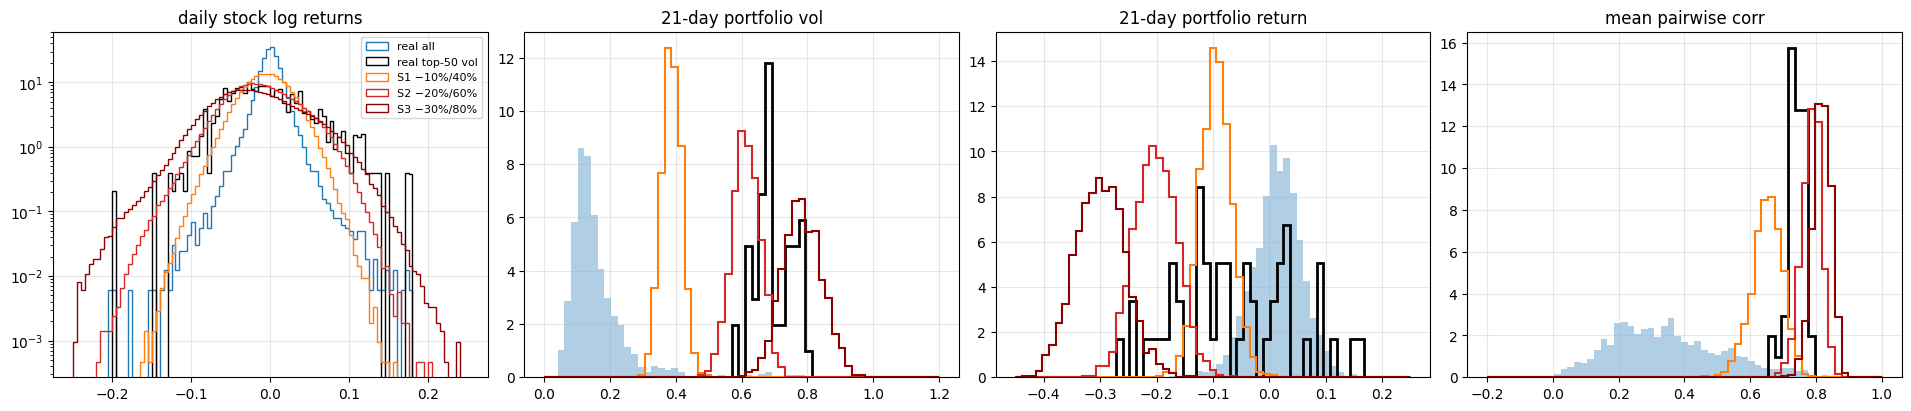

In [29]:
if not ((SRC['rl paths'] / 'paths.npz').exists() and have['prices (2004-)']):
    note('需要 rl_paths/paths.npz 與價格檔才能畫分布，略過。')
else:
    fig, axes = plt.subplots(1, 4, figsize=(19, 4), constrained_layout=True)
    bins = np.linspace(-.25, .25, 101)
    axes[0].hist(real_rc.ravel(), bins=bins, density=True, histtype='step', color='tab:blue', label='real all')
    axes[0].hist(real_rc[top].ravel(), bins=bins, density=True, histtype='step', color='k', label='real top-50 vol')
    for s in sorted(set(scen.tolist())):
        axes[0].hist(syn_rc[scen == s].ravel(), bins=bins, density=True, histtype='step', color=COLORS[s], label=NAMES[s])
    axes[0].set_yscale('log'); axes[0].set_title('daily stock log returns')
    for ax, (rv, sv, title, rng_) in zip(axes[1:], [(real_V, syn_V, '21-day portfolio vol', (0, 1.2)),
                                                   (real_R, syn_R, '21-day portfolio return', (-.45, .25)),
                                                   (real_C, syn_C, 'mean pairwise corr', (-.2, 1))]):
        b = np.linspace(*rng_, 60)
        ax.hist(rv, bins=b, density=True, alpha=.35, color='tab:blue', label='real all')
        ax.hist(rv[top], bins=b, density=True, histtype='step', lw=2, color='k', label='real top-50 vol')
        for s in sorted(set(scen.tolist())):
            ax.hist(sv[scen == s], bins=b, density=True, histtype='step', lw=1.5, color=COLORS[s], label=NAMES[s])
        ax.set_title(title)
    for ax in axes: ax.grid(alpha=.3)
    axes[0].legend(fontsize=8)
    fig.savefig(EXPORT / 'rl_paths_distributions.png', dpi=130); plt.show()

### 6.2 路徑樣貌

每個情境以固定亂數種子抽 4 條，不挑選。黑線為真實 50 天歷史（組合），彩色為生成的 21 天，灰線為 10 檔個股；價格除以起點收盤。
最後一張把各情境 40 條生成路徑與報酬／波動最接近的 10 個真實窗口疊在一起比較形狀。

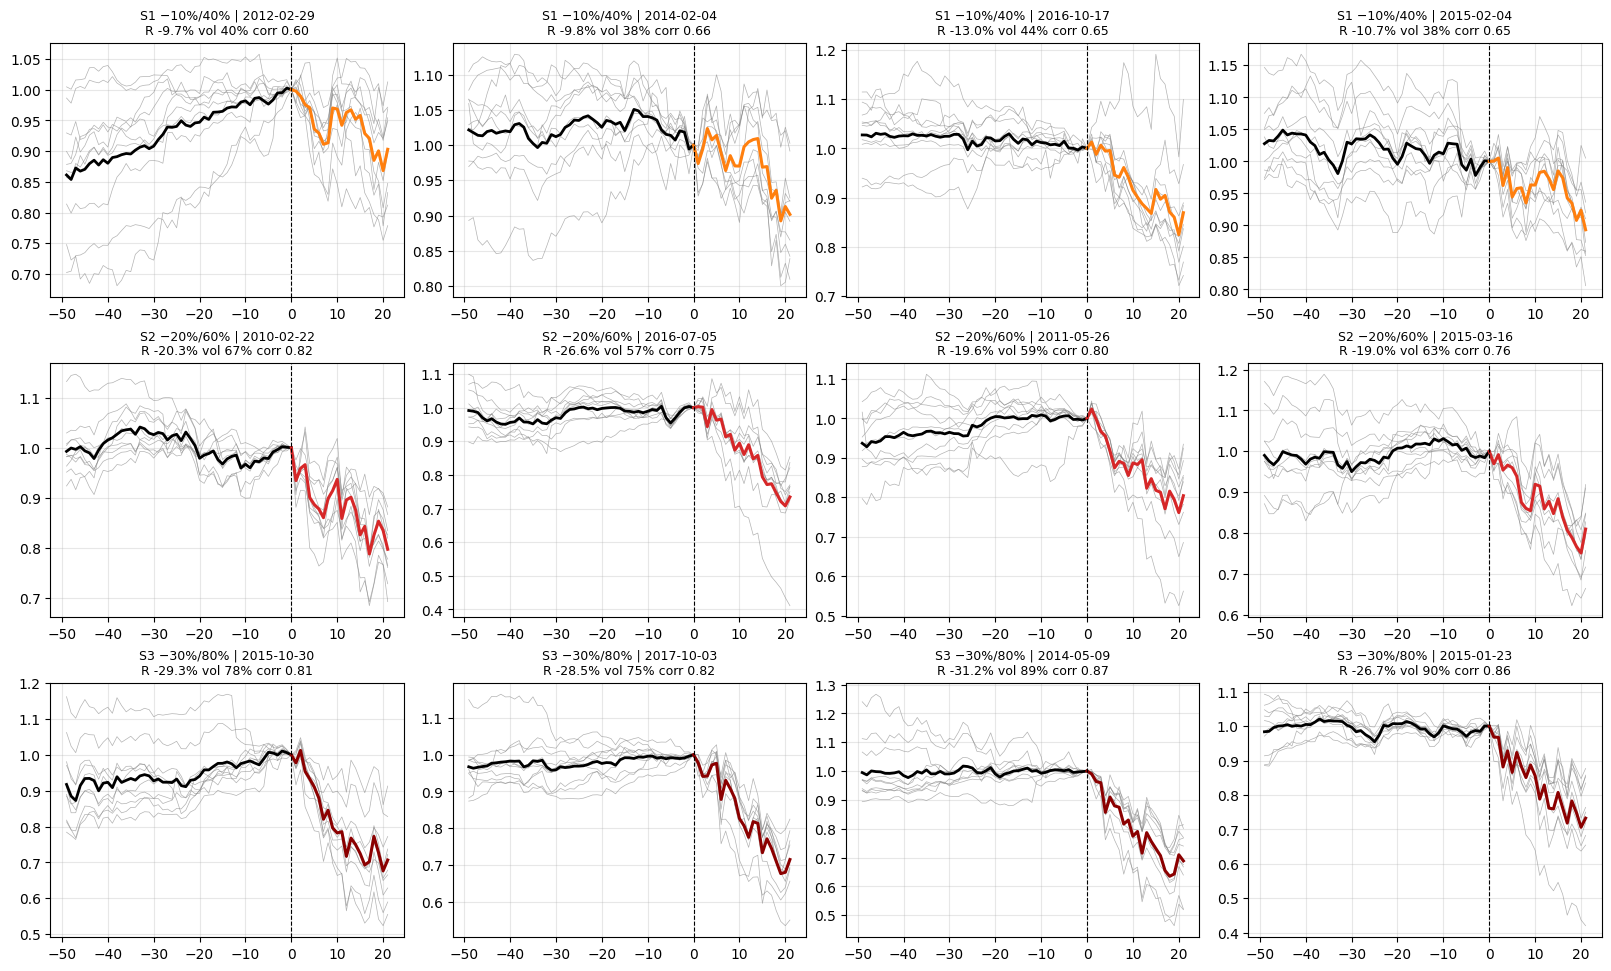

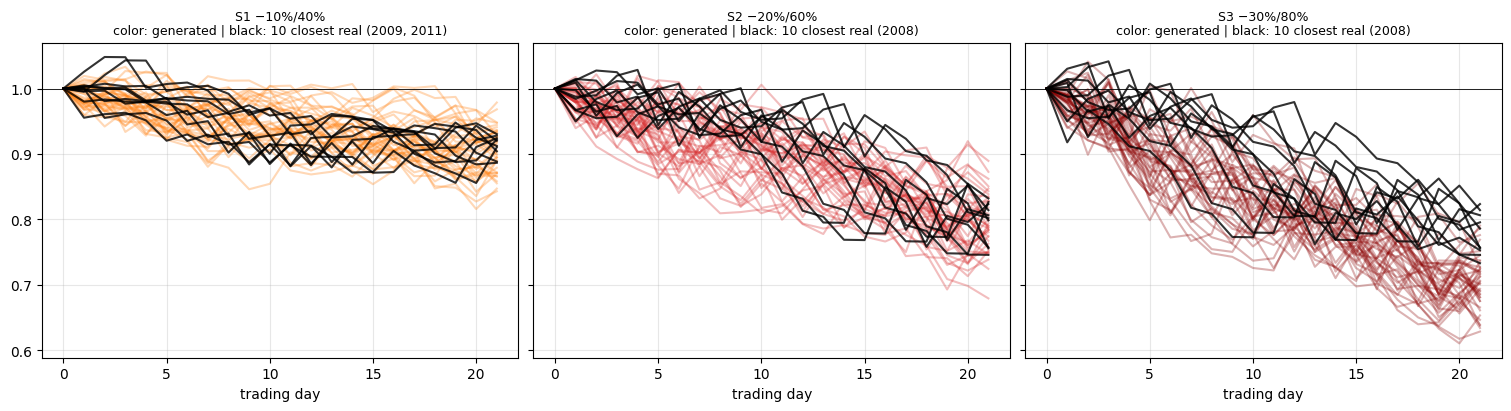

In [30]:
if not ((SRC['rl paths'] / 'paths.npz').exists() and have['prices (2004-)']):
    note('需要 rl_paths/paths.npz 與價格檔才能畫樣本路徑，略過。')
else:
    rng = np.random.default_rng(0); W = 50
    sc_list = sorted(set(scen.tolist()))
    fig, axes = plt.subplots(len(sc_list), 4, figsize=(16, 3.2 * len(sc_list)), squeeze=False, constrained_layout=True)
    for r, s in enumerate(sc_list):
        for c, j in enumerate(rng.choice(np.flatnonzero(scen == s), 4, replace=False)):
            a = anchors[j]; ax = axes[r, c]
            full = np.vstack([C[a - W + 1:a + 1], syn_close[j]]) / C[a]
            x = np.arange(-W + 1, 22)
            ew = ew_path(full / full[0]); ew = ew / ew[W - 1]
            ax.plot(x, full, color='gray', lw=.5, alpha=.6)
            ax.plot(x[:W], ew[:W], color='k', lw=2); ax.plot(x[W - 1:], ew[W - 1:], color=COLORS[s], lw=2.2)
            ax.axvline(0, color='k', ls='--', lw=.8); ax.grid(alpha=.3)
            ax.set_title(f'{NAMES[s]} | {str(z["anchor_dates"][j])}\nR {syn_R[j]:+.1%} vol {syn_V[j]:.0%} corr {syn_C[j]:.2f}', fontsize=9)
    fig.savefig(EXPORT / 'rl_paths_examples.png', dpi=130); plt.show()

    real_paths = np.stack([ew_path(C[s - 1:s + 21] / C[s - 1]) for s in starts])
    fig, axes = plt.subplots(1, len(sc_list), figsize=(5 * len(sc_list), 4), sharey=True, constrained_layout=True)
    for ax, s in zip(np.atleast_1d(axes), sc_list):
        m = scen == s
        for j in rng.choice(np.flatnonzero(m), 40, replace=False):
            ax.plot(ew_path(np.vstack([C[anchors[j]], syn_close[j]]) / C[anchors[j]]), color=COLORS[s], alpha=.3)
        d = np.hypot((real_R - syn_R[m].mean()) / real_R.std(), (real_V - syn_V[m].mean()) / real_V.std())
        near = np.argsort(d)[:10]
        for k in near: ax.plot(real_paths[k], color='k', lw=1.5, alpha=.8)
        yrs = sorted({str(dates[starts[k]].year) for k in near})
        ax.set_title(f'{NAMES[s]}\ncolor: generated | black: 10 closest real ({", ".join(yrs)})', fontsize=9)
        ax.axhline(1, color='k', lw=.6); ax.grid(alpha=.3); ax.set_xlabel('trading day')
    fig.savefig(EXPORT / 'rl_paths_vs_closest_real.png', dpi=130); plt.show()

## 7. FinRL 設定核對

逐一讀取各 run 的 `config.json`，確認三組除了 group 與 seed 之外設定相同（價格與合成路徑檔、期間、步數、手續費）。

In [ ]:
RUNS = sorted(p for p in SRC['FinRL v1'].iterdir() if p.is_dir()) if have['FinRL v1'] else []
if not RUNS:
    note('找不到 FinRL v1 結果，略過第 7–10 節。')
else:
    cfgs = []
    for run in RUNS:
        c = json.loads((run / 'config.json').read_text())
        cfgs.append({'run': run.name, **{k: (v if not isinstance(v, list) else ' '.join(map(str, v))) for k, v in c.items()}})
    cfg = pd.DataFrame(cfgs).set_index('run')
    varying = [c for c in cfg.columns if cfg[c].astype(str).nunique() > 1]
    print('settings that differ between runs:', varying)
    unexpected = set(varying) - {'groups', 'seeds', 'out'}
    #assert not unexpected, f'runs differ in {unexpected}'
    display(cfg.iloc[:1].T.rename(columns={cfg.index[0]: 'shared setting'}))

settings that differ between runs: ['out', 'groups', 'seeds', 'evaluated_from']


AssertionError: runs differ in {'evaluated_from'}

## 8. FinRL 測試結果（2020–2022 連續回測）

每組 3 個 seed 的平均 ± 標準差；起點 1/11、測試開始時一次扣除建倉成本。基準為同樣扣建倉成本的 1/11 與 1/10 買進持有。
下方第二張表為各組相對 A 組的差值（百分點），並列 seed 標準差作為雜訊參考；未做顯著性檢定。

In [ ]:
if RUNS:
    S = pd.concat([pd.read_csv(r / 'summary.csv') for r in RUNS if (r / 'summary.csv').exists()], ignore_index=True)
    S = S.drop_duplicates(subset=['group', 'seed', 'period'])
    PERIODS = ['2020', '2021', '2022', '2020-2022']
    S['period'] = S['period'].astype(str)
    order = [g for g in ['A', 'B20', 'B50'] if g in set(S.group)] + sorted(set(S.group) - {'A', 'B20', 'B50', 'buy_hold_1_11', 'buy_hold_1_10'}) + ['buy_hold_1_11', 'buy_hold_1_10']
    metrics = ['return', 'max_drawdown', 'worst_21d_return', 'sharpe_0rf', 'mean_stock_weight']
    agg = S.groupby(['period', 'group'])[metrics].agg(['mean', 'std'])
    fmt = lambda m, s, k: '—' if pd.isna(m) else (f'{m:+.3f}' if k in ('sharpe_0rf', 'mean_stock_weight') else f'{m:+.1%}') + ('' if pd.isna(s) else f' ± {s:.3f}' if k in ('sharpe_0rf', 'mean_stock_weight') else f' ± {s:.1%}')
    for per in PERIODS:
        rows = []
        for g in order:
            if (per, g) not in agg.index: continue
            rows.append({'group': g, **{k: fmt(agg.loc[(per, g), (k, 'mean')], agg.loc[(per, g), (k, 'std')], k) for k in metrics}})
        display(Markdown(f'**{per}**')); display(pd.DataFrame(rows).set_index('group'))
    agg.to_csv(EXPORT / 'finrl_by_group.csv')

    base = S[S.group == 'A'].groupby('period')[['return', 'max_drawdown', 'worst_21d_return']].mean()
    rows = []
    for g in [g for g in order if g != 'A']:
        sub = S[S.group == g]
        for per in PERIODS:
            x = sub[sub.period == per]
            if x.empty or per not in base.index: continue
            rows.append({'group': g, 'period': per,
                         'Δ return vs A (pp)': 100 * (x['return'].mean() - base.loc[per, 'return']),
                         'Δ max DD vs A (pp)': 100 * (x['max_drawdown'].mean() - base.loc[per, 'max_drawdown']),
                         'seed std of return (pp)': 100 * x['return'].std() if len(x) > 1 else np.nan})
    display(pd.DataFrame(rows).style.format('{:+.2f}', subset=['Δ return vs A (pp)', 'Δ max DD vs A (pp)']).format('{:.2f}', subset=['seed std of return (pp)']))

**2020**

,return,max_drawdown,worst_21d_return,sharpe_0rf,mean_stock_weight
group,,,,,
A,+20.9% ± 3.0%,-24.5% ± 0.1%,-24.1% ± 0.2%,+0.617 ± 0.074,+0.906 ± 0.011
B20,+19.3% ± 1.3%,-24.6% ± 0.4%,-24.1% ± 0.3%,+0.575 ± 0.039,+0.930 ± 0.025
B50,+18.6% ± 2.6%,-24.8% ± 1.8%,-24.3% ± 1.6%,+0.555 ± 0.092,+0.924 ± 0.023
buy_hold_1_11,+18.6%,-24.4%,-24.0%,+0.562,—
buy_hold_1_10,+20.5%,-26.7%,-26.2%,+0.553,—


**2021**

,return,max_drawdown,worst_21d_return,sharpe_0rf,mean_stock_weight
group,,,,,
A,+17.6% ± 0.3%,-6.7% ± 0.2%,-4.5% ± 0.2%,+1.365 ± 0.058,+0.904 ± 0.011
B20,+16.8% ± 0.8%,-6.9% ± 0.3%,-4.8% ± 0.5%,+1.308 ± 0.063,+0.931 ± 0.024
B50,+17.5% ± 0.7%,-6.9% ± 0.2%,-4.8% ± 0.1%,+1.338 ± 0.030,+0.925 ± 0.023
buy_hold_1_11,+18.8%,-7.3%,-5.3%,+1.375,—
buy_hold_1_10,+20.4%,-7.9%,-5.8%,+1.372,—


**2022**

,return,max_drawdown,worst_21d_return,sharpe_0rf,mean_stock_weight
group,,,,,
A,-19.8% ± 1.0%,-26.7% ± 0.7%,-13.1% ± 0.2%,-0.998 ± 0.034,+0.907 ± 0.006
B20,-18.8% ± 0.6%,-26.9% ± 0.3%,-13.2% ± 0.2%,-0.957 ± 0.037,+0.931 ± 0.024
B50,-19.5% ± 0.8%,-27.2% ± 1.3%,-13.2% ± 0.3%,-0.996 ± 0.009,+0.920 ± 0.019
buy_hold_1_11,-20.0%,-26.6%,-13.9%,-0.998,—
buy_hold_1_10,-21.3%,-28.4%,-14.9%,-0.993,—


**2020-2022**

,return,max_drawdown,worst_21d_return,sharpe_0rf,mean_stock_weight
group,,,,,
A,+14.1% ± 1.8%,-26.7% ± 0.7%,-24.1% ± 0.2%,+0.192 ± 0.021,+0.906 ± 0.009
B20,+13.2% ± 2.0%,-27.1% ± 0.4%,-24.1% ± 0.3%,+0.182 ± 0.026,+0.931 ± 0.025
B50,+12.2% ± 2.9%,-27.2% ± 1.3%,-24.3% ± 1.6%,+0.169 ± 0.044,+0.923 ± 0.021
buy_hold_1_11,+12.8%,-26.6%,-24.0%,+0.175,—
buy_hold_1_10,+14.0%,-28.4%,-26.2%,+0.174,—


,group,period,Δ return vs A (pp),Δ max DD vs A (pp),seed std of return (pp)
0,B20,2020,-1.65,-0.01,1.25
1,B20,2021,-0.81,-0.18,0.77
2,B20,2022,+1.04,-0.23,0.56
3,B20,2020-2022,-0.85,-0.34,1.99
4,B50,2020,-2.32,-0.25,2.59
5,B50,2021,-0.16,-0.22,0.68
6,B50,2022,+0.34,-0.51,0.78
7,B50,2020-2022,-1.84,-0.52,2.88
8,buy_hold_1_11,2020,-2.33,+0.15,nan
9,buy_hold_1_11,2021,+1.16,-0.64,nan


## 9. 策略有沒有依行情調整持股

起始 1/11 的持股比例為 10/11 ≈ 0.909。若策略會依行情減碼，持股比例應在崩盤期明顯下降。
表中為每個 run 在 2020–2022 的持股比例範圍、標準差、2020 年 3 月平均與每日換手率。

,min,max,std,Mar-2020 mean,daily turnover
run,,,,,
A_seed0,0.886,0.938,0.0109,0.899,0.0108
A_seed1,0.873,0.919,0.0076,0.901,0.0107
A_seed2,0.885,0.928,0.0070,0.917,0.0105
B20_seed0,0.899,0.931,0.0063,0.919,0.0071
B20_seed1,0.897,0.924,0.0032,0.909,0.0089
B20_seed2,0.909,0.972,0.0069,0.957,0.0133
B50_seed0,0.891,0.927,0.0070,0.917,0.0074
B50_seed1,0.874,0.966,0.0130,0.919,0.0090
B50_seed2,0.867,0.930,0.0104,0.892,0.0080


max std across runs: 0.0130 (start weight 10/11 = 0.909)


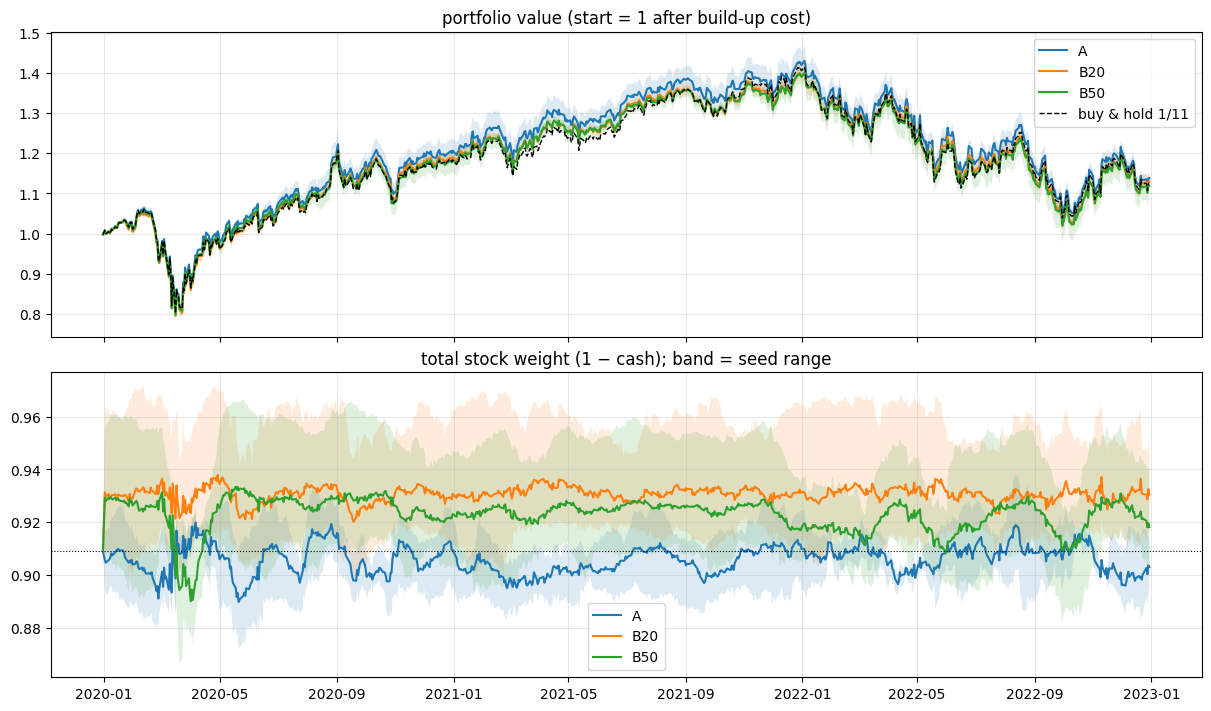

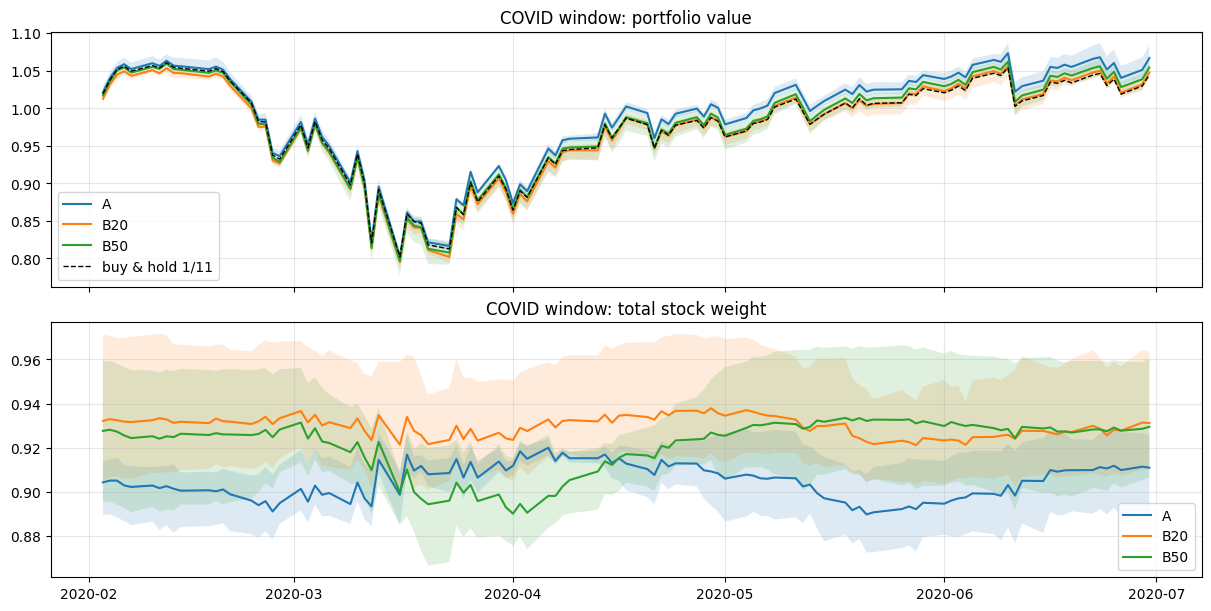

In [ ]:
if RUNS:
    D = []
    for r in RUNS:
        for f in r.glob('*_seed*_test_daily.csv'):
            g, s = f.stem.replace('_test_daily', '').rsplit('_seed', 1)
            D.append(pd.read_csv(f, parse_dates=['date']).assign(group=g, seed=int(s)))
    D = pd.concat(D, ignore_index=True)
    D['stock_weight'] = 1 - D.cash_weight
    rows = []
    for (g, s), d in D.groupby(['group', 'seed']):
        mar = d[(d.date >= '2020-03-01') & (d.date <= '2020-03-31')].stock_weight
        rows.append({'run': f'{g}_seed{s}', 'min': d.stock_weight.min(), 'max': d.stock_weight.max(),
                     'std': d.stock_weight.std(), 'Mar-2020 mean': mar.mean(), 'daily turnover': d.turnover.iloc[1:].mean()})
    wt = pd.DataFrame(rows).set_index('run')
    display(wt.style.format('{:.3f}').format('{:.4f}', subset=['std', 'daily turnover']))
    wt.to_csv(EXPORT / 'finrl_stock_weight_by_run.csv')
    print(f'max std across runs: {wt["std"].max():.4f} (start weight 10/11 = {10/11:.3f})')

    BH = pd.read_csv(RUNS[0] / 'buy_hold_1_11_test_daily.csv', parse_dates=['date'])
    groups = [g for g in ['A', 'B20', 'B50'] if g in set(D.group)]
    def band(ax, col, data, title):
        for g in groups:
            st = data[data.group == g].groupby('date')[col].agg(['mean', 'min', 'max'])
            ax.plot(st.index, st['mean'], label=g); ax.fill_between(st.index, st['min'], st['max'], alpha=.15)
        ax.set_title(title); ax.grid(alpha=.3)
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
    band(axes[0], 'value', D, 'portfolio value (start = 1 after build-up cost)')
    axes[0].plot(BH.date, BH.value, 'k--', lw=1, label='buy & hold 1/11'); axes[0].legend()
    band(axes[1], 'stock_weight', D, 'total stock weight (1 − cash); band = seed range')
    axes[1].axhline(10/11, color='k', ls=':', lw=.8); axes[1].legend()
    fig.savefig(EXPORT / 'finrl_value_and_weight.png', dpi=130); plt.show()

    cv = D[(D.date >= '2020-02-01') & (D.date <= '2020-06-30')]
    bh = BH[(BH.date >= '2020-02-01') & (BH.date <= '2020-06-30')]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
    band(axes[0], 'value', cv, 'COVID window: portfolio value'); axes[0].plot(bh.date, bh.value, 'k--', lw=1, label='buy & hold 1/11'); axes[0].legend()
    band(axes[1], 'stock_weight', cv, 'COVID window: total stock weight'); axes[1].legend()
    fig.savefig(EXPORT / 'finrl_covid.png', dpi=130); plt.show()

## 10. 選模與驗證

每 2.5 萬步以 2018–2019 連續回測評分，取最高者。若最佳步數多落在訓練早期，代表後續訓練未改善驗證表現。

timesteps  valid_final_value
group seed                              
A     0        175000           1.446160
      1        100000           1.424248
      2         50000           1.412996
B20   0         25000           1.419998
      1        150000           1.437141
      2        325000           1.460087
B50   0         25000           1.438303
      1        175000           1.437150
      2         25000           1.420689

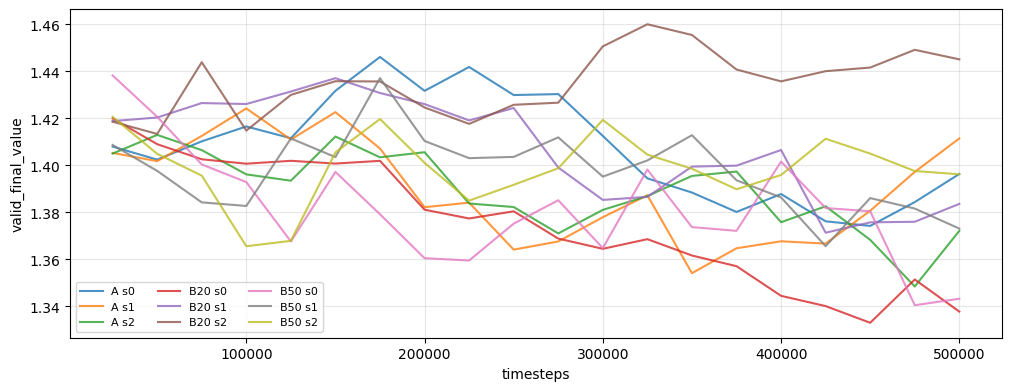

In [ ]:
if RUNS:
    V = []
    for r in RUNS:
        for f in r.glob('*_seed*_valid.csv'):
            g, s = f.stem.replace('_valid', '').rsplit('_seed', 1)
            V.append(pd.read_csv(f).assign(group=g, seed=int(s)))
    if V:
        V = pd.concat(V, ignore_index=True)
        col = 'valid_score' if 'valid_score' in V else 'valid_final_value'
        best = V.loc[V.groupby(['group', 'seed'])[col].idxmax(), ['group', 'seed', 'timesteps', col]]
        display(best.set_index(['group', 'seed']))
        fig, ax = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
        for (g, s), v in V.groupby(['group', 'seed']):
            ax.plot(v.timesteps, v[col], label=f'{g} s{s}', alpha=.8)
        ax.set_xlabel('timesteps'); ax.set_ylabel(col); ax.grid(alpha=.3); ax.legend(ncol=3, fontsize=8)
        fig.savefig(EXPORT / 'finrl_validation.png', dpi=130); plt.show()

## 11. 崩盤反應診斷（若已執行）

僅在新版訓練腳本（含 `--crash-diag-n`）跑過時存在。讓策略跑「前 10 天真實、接著 21 天合成崩盤」的訓練期回合，
比較崩盤前與崩盤後期的持股比例；`change_late_vs_pre` 越負代表減碼越多。真實回合為對照。

In [ ]:
files = [f for base in (SRC['FinRL v1'], SRC['FinRL sanity (optional)']) if base.exists() for f in base.glob('*/*_crash_response.csv')]
if not files:
    note('尚無崩盤反應診斷結果（第一輪使用的訓練腳本沒有此功能）。')
else:
    cr = pd.concat([pd.read_csv(f).assign(run=f.parent.name) for f in files], ignore_index=True)
    display(cr.groupby(['run', 'source', 'scenario'], dropna=False)[['pre', 'early_crash', 'late_crash', 'change_late_vs_pre']].mean().round(4))

> 尚無崩盤反應診斷結果（第一輪使用的訓練腳本沒有此功能）。

## 判讀與限制

- **生成器必須看過真實崩盤。** 未看過崩盤的生成器在極端條件下報酬跌不下去、波動爆炸（第 4 節）；加入 2008 後報酬幾乎對準目標。
- **條件需校準。** 看過 2008 的模型波動系統性偏低，輸入與輸出的對應被壓縮；經校準後三組實際約為 −10%／39%、−20%／62%、−30%／79%（第 5 節）。報告應使用實際生成值，不應使用輸入值或對輸入計算的命中率。
- **合成崩盤的量級合理但不完全等同真實。** 情境 3 的跌幅略超出生成器看過的最嚴重窗口；情境 2、3 的 10 檔相關性略高於真實高波動窗口（第 6 節）。
- **FinRL 第一輪無法回答主要問題。** 三組與 1/11 買進持有幾乎相同，持股比例幾乎不隨行情變動（第 8–9 節），組間差異不大於 seed 間差異。原因可能在 PPO 設定（探索幅度、選模標準）或本次環境的 state 正規化與 1/11 起始，需先確認策略能學會減碼，再比較資料來源。
- 生成器只訓練一次（單一 seed）；FinRL 每組 3 個 seed；2018–2019 選模期偏多頭；只有報酬與波動兩個條件，無法控制急跌、陰跌、V 型反彈等形狀。
- 以上判讀依第一輪輸出撰寫；若重跑，請以本 notebook 重算的表格為準。